# Topic: 
# Comparative Analysis of Machine Learning Algorithms for Breast Cancer Classification Using the Wisconsin Dataset

In [1]:
# Importing dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report, roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import GridSearchCV, cross_val_score
from tabulate import tabulate

In [2]:
# Loading Data
Dataset = pd.read_csv("Data.csv")
Dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Data Cleaning 

In [3]:
Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
# Dropping un-useful columns 
Dataset.drop(["id", "Unnamed: 32"], axis = 1, inplace=True)
Dataset.tail()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


# Handling Missing Values

In [5]:
# defining a fuction to check for missing values
def missing_values():
    missing = Dataset.isnull().sum()
    missing = missing[missing > 0]
    
    if len(missing) > 0:
        return f"Missing Values:\n{missing}"
    else:
        return "No missing values"

missing_values()

'No missing values'

In [6]:
# Checking unique values in the target variables
print(f"Unique Values: {Dataset.diagnosis.unique()}")
print("   \nNOTE:\nM: Malignant \nB: Benign")
print("-"*20)
print(Dataset.diagnosis.value_counts())

Unique Values: ['M' 'B']
   
NOTE:
M: Malignant 
B: Benign
--------------------
diagnosis
B    357
M    212
Name: count, dtype: int64


# Checking for inconsistence data and Typos

In [7]:
# for col in Dataset.columns:
#     print(f"Unique values in {col}: \n{Dataset[col].unique()}\n{'-'*70}")
# print("See Unique values above")    

In [8]:
Dataset[Dataset.duplicated(keep = False)]

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst


# EXPORATORY DATA ANALYSIS

In [9]:
Dataset.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [10]:
#setting plot style for all the plots
sns.set(style = 'whitegrid')

In [11]:
Dataset.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

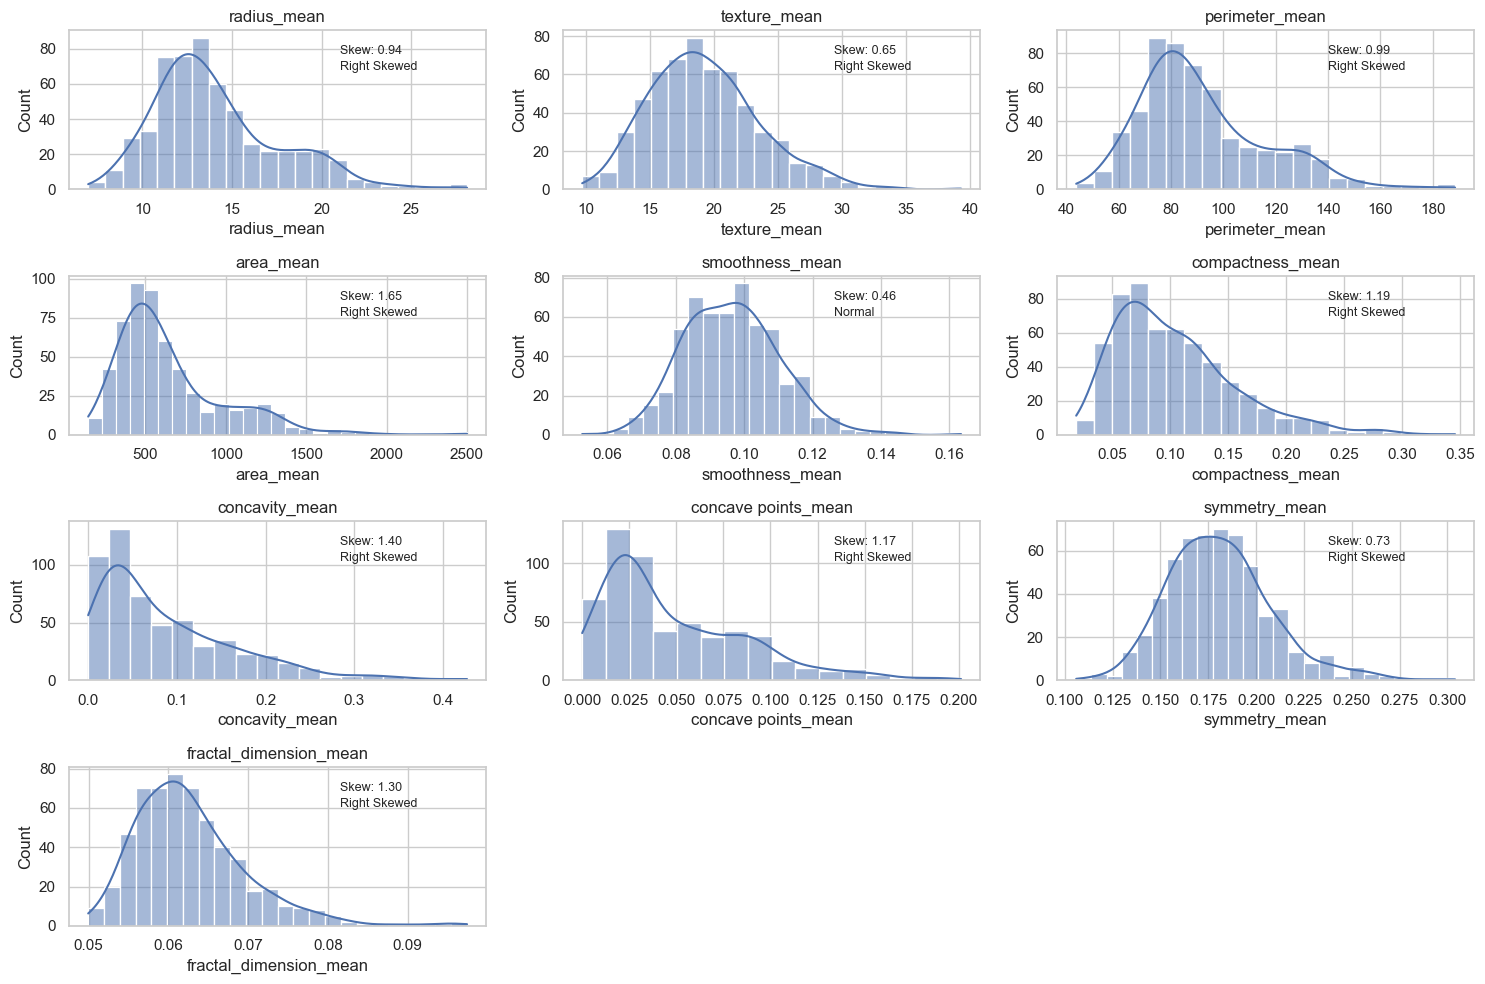

In [12]:
# Distributions for mean
plt.figure(figsize=(15, 10))

for i, columns in enumerate([
    'radius_mean', 'texture_mean', 'perimeter_mean',
    'area_mean', 'smoothness_mean', 'compactness_mean',
    'concavity_mean', 'concave points_mean', 'symmetry_mean',
    'fractal_dimension_mean'
], 1):
    
    plt.subplot(4, 3, i)
    
    data = Dataset[columns]
    skewness = data.skew()
    
    sns.histplot(data, kde=True)
    
    # Determine skew type
    if skewness > 0.5:
        label = "Right Skewed"
    elif skewness < -0.5:
        label = "Left Skewed"
    else:
        label = "Normal"
    
    # Add text inside plot
    plt.text(0.65, 0.85, f"Skew: {skewness:.2f}",
             transform=plt.gca().transAxes, fontsize=9)
    
    plt.text(0.65, 0.75, label,
             transform=plt.gca().transAxes, fontsize=9)
    
    plt.title(columns)
plt.tight_layout()
plt.show()

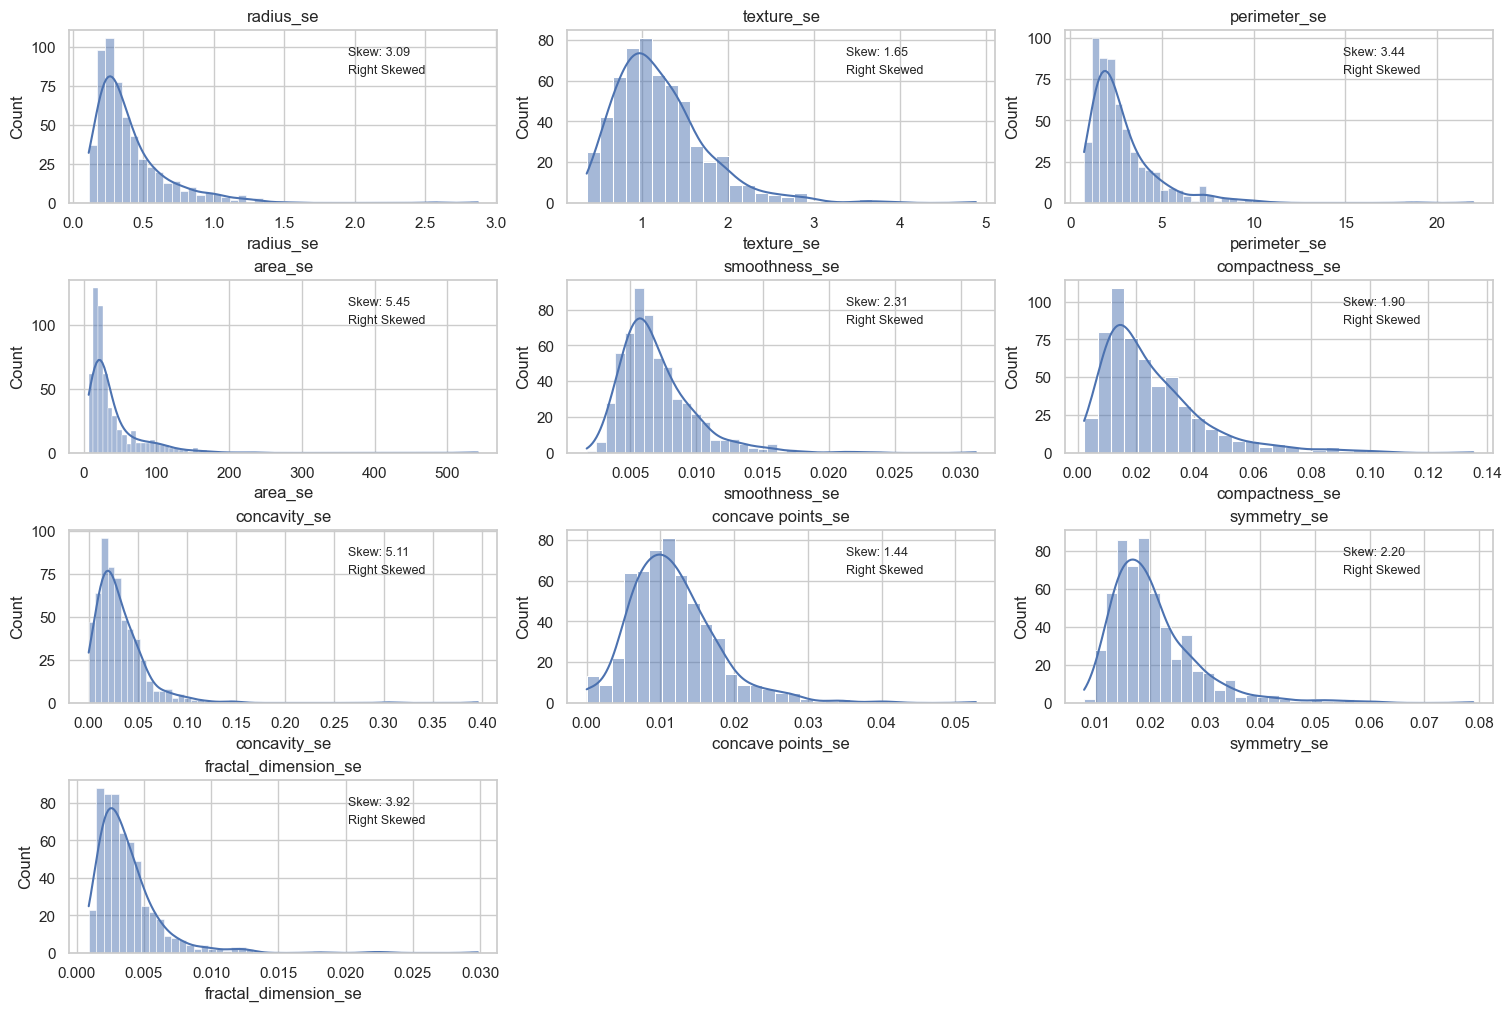

In [13]:
# Distribution for se
plt.figure(figsize=(15, 10), constrained_layout=True)

for i, columns in enumerate([
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
    'fractal_dimension_se'
], 1):
    
    plt.subplot(4, 3, i)
    
    data = Dataset[columns]
    skewness = data.skew()
    
    sns.histplot(data, kde=True)
    
    # Determine skew type
    if skewness > 0.5:
        label = "Right Skewed"
    elif skewness < -0.5:
        label = "Left Skewed"
    else:
        label = "Normal"
    
    # Add text inside plot
    plt.text(0.65, 0.85, f"Skew: {skewness:.2f}",
             transform=plt.gca().transAxes, fontsize=9)
    
    plt.text(0.65, 0.75, label,
             transform=plt.gca().transAxes, fontsize=9)
    
    plt.title(columns)

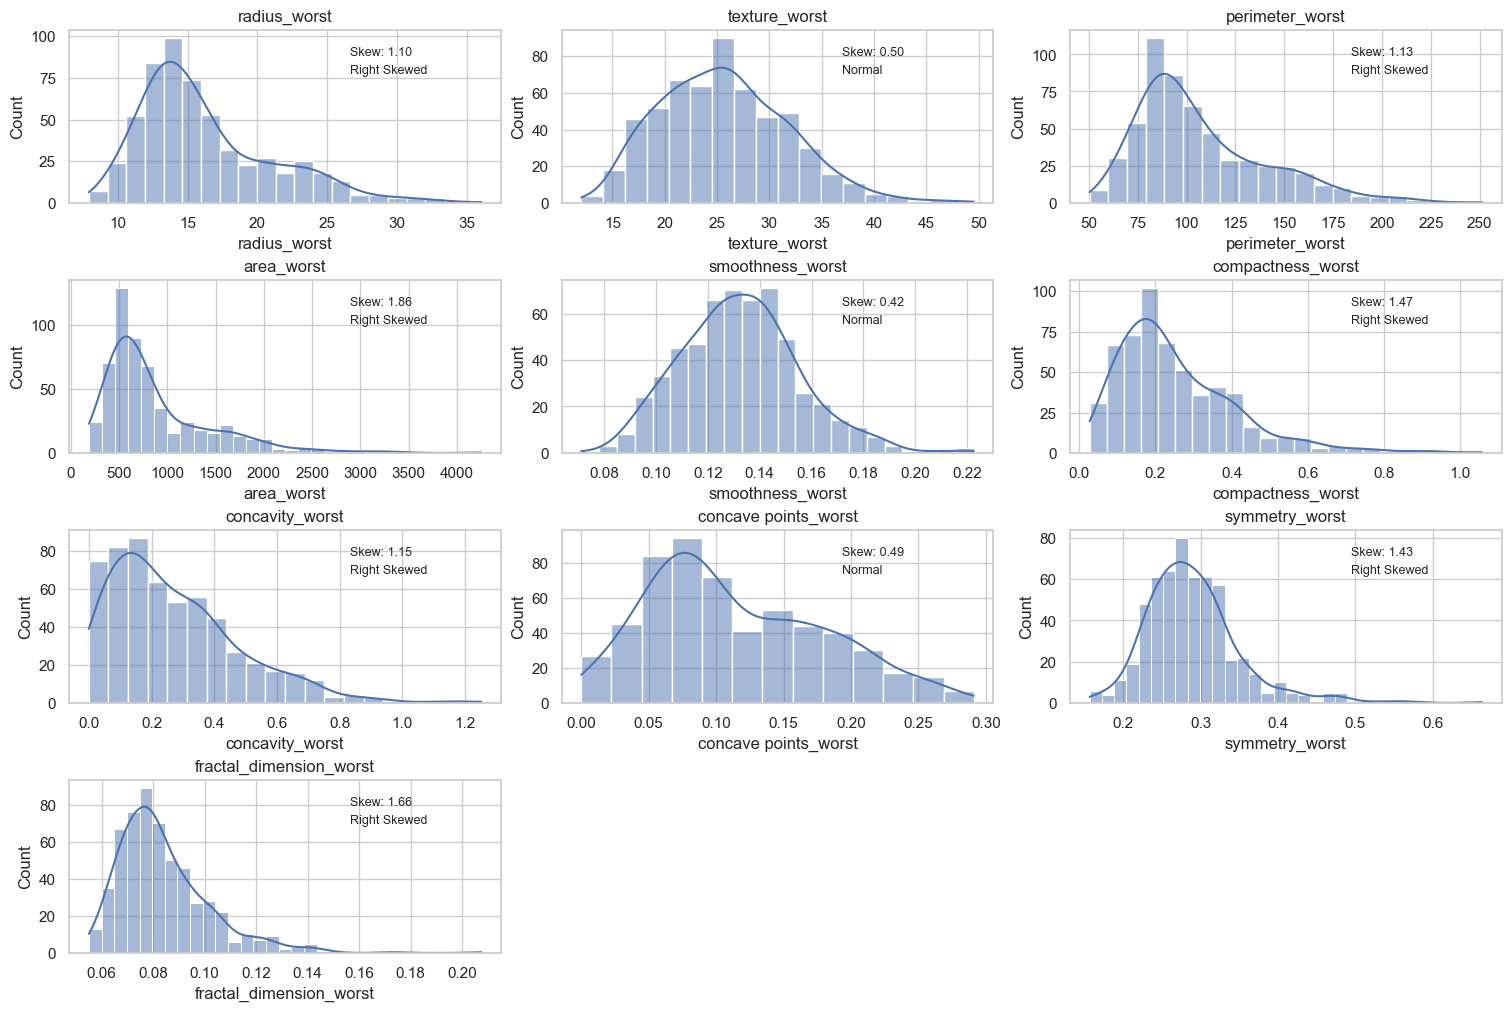

In [14]:
# Distributions for worst
plt.figure(figsize=(15, 10), constrained_layout=True)

for i, columns in enumerate([
    'radius_worst', 'texture_worst',
    'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave points_worst',
    'symmetry_worst', 'fractal_dimension_worst'
], 1):
    
    plt.subplot(4, 3, i)
    
    data = Dataset[columns]
    skewness = data.skew()
    
    sns.histplot(data, kde=True)
    
    # Determine skew type
    if skewness > 0.5:
        label = "Right Skewed"
    elif skewness < -0.5:
        label = "Left Skewed"
    else:
        label = "Normal"
    
    # Add text inside plot
    plt.text(0.65, 0.85, f"Skew: {skewness:.2f}",
             transform=plt.gca().transAxes, fontsize=9)
    
    plt.text(0.65, 0.75, label,
             transform=plt.gca().transAxes, fontsize=9)
    
    plt.title(columns)

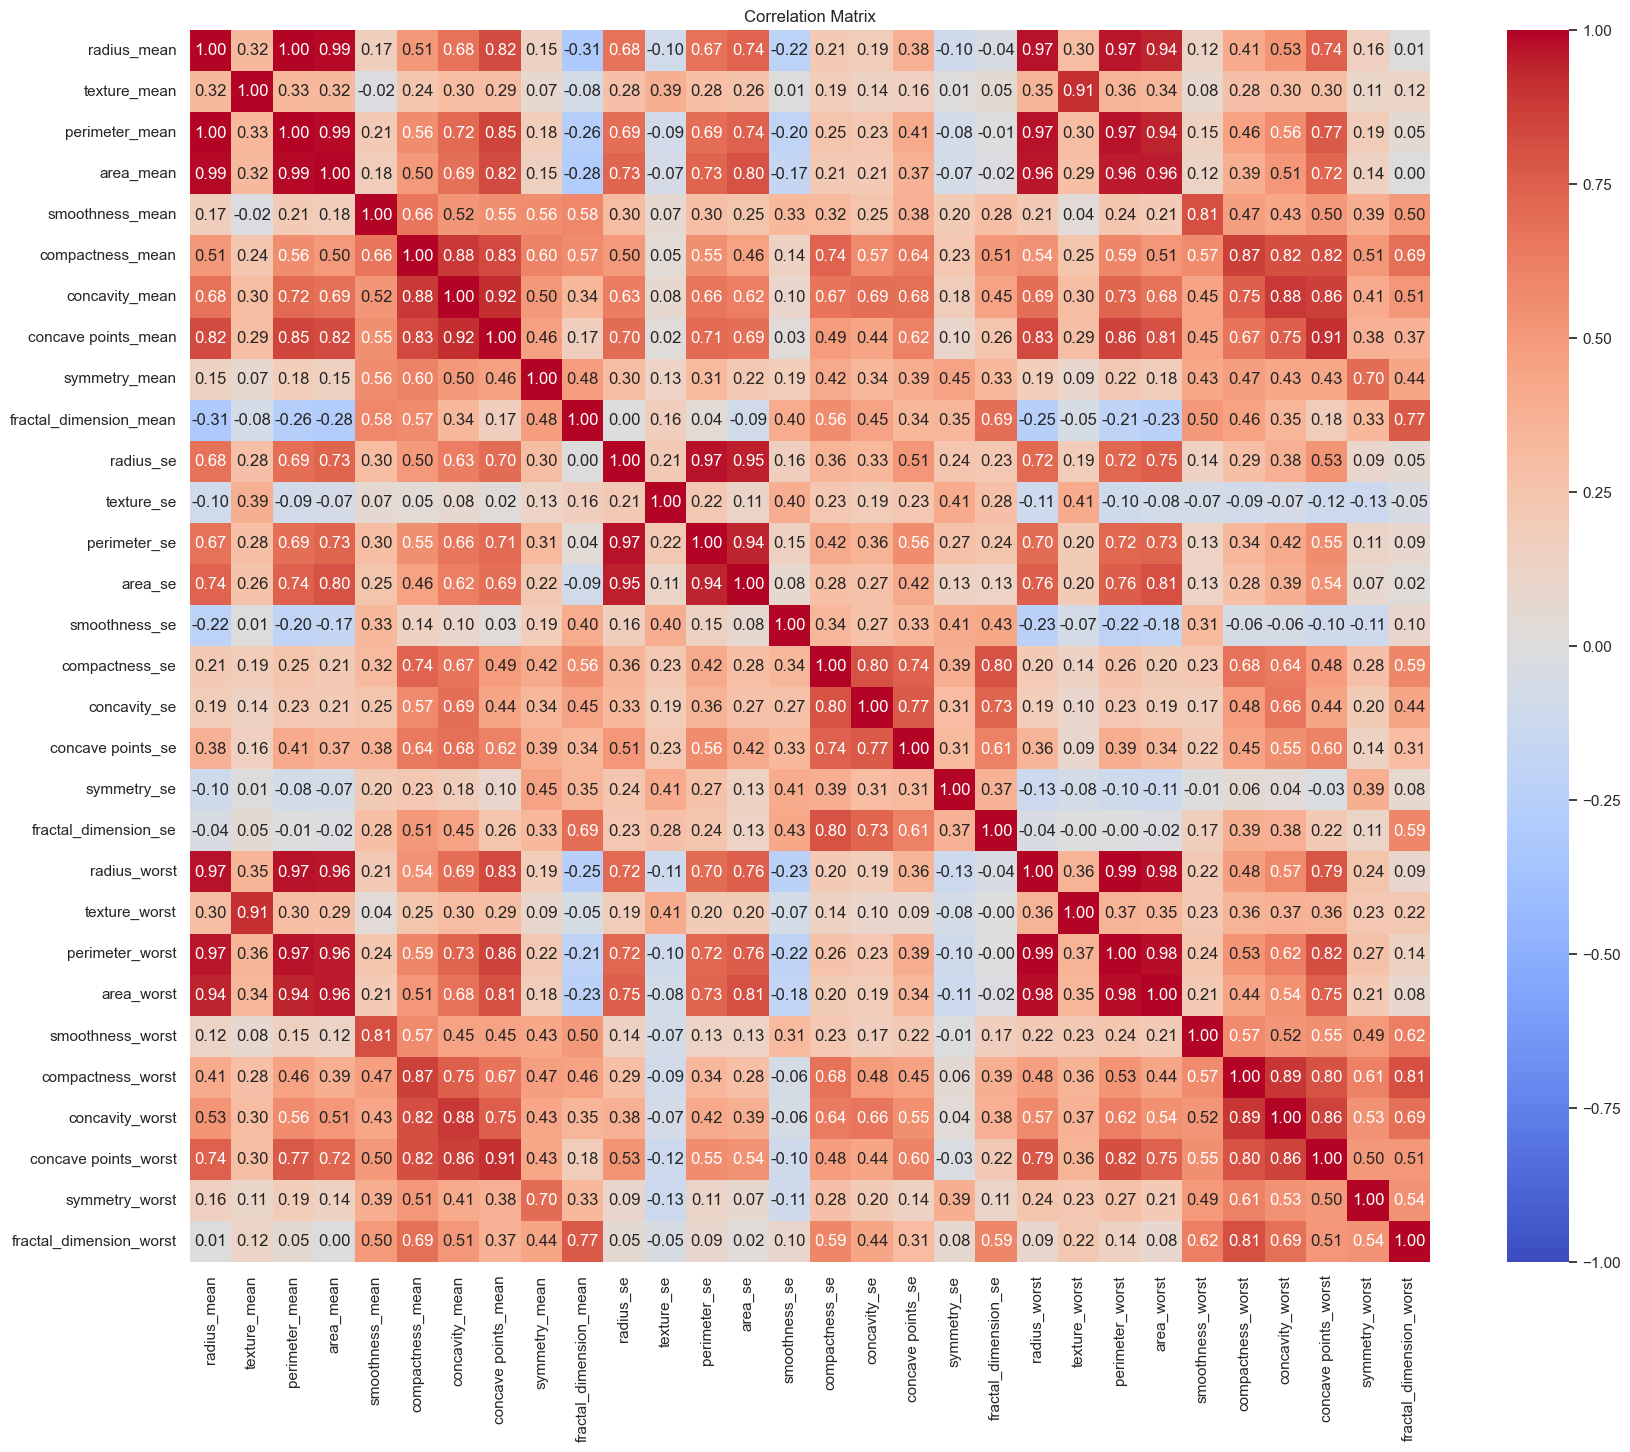

In [15]:
# Correlation in numerical Data 
corr_matrix = Dataset.corr(numeric_only=True) 

# Plot the correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [16]:
# Get strong correlations
strong_corr = corr_matrix.abs() > 0.7

# Remove self-correlation
np.fill_diagonal(strong_corr.values, False)

print("Strong Correlations (|corr| > 0.7):\n")

for col in strong_corr.columns:
    for row in strong_corr.index:
        if strong_corr.loc[row, col]:
            print(f"{row} <-> {col} = {corr_matrix.loc[row, col]:.2f}")

Strong Correlations (|corr| > 0.7):

perimeter_mean <-> radius_mean = 1.00
area_mean <-> radius_mean = 0.99
concave points_mean <-> radius_mean = 0.82
area_se <-> radius_mean = 0.74
radius_worst <-> radius_mean = 0.97
perimeter_worst <-> radius_mean = 0.97
area_worst <-> radius_mean = 0.94
concave points_worst <-> radius_mean = 0.74
texture_worst <-> texture_mean = 0.91
radius_mean <-> perimeter_mean = 1.00
area_mean <-> perimeter_mean = 0.99
concavity_mean <-> perimeter_mean = 0.72
concave points_mean <-> perimeter_mean = 0.85
area_se <-> perimeter_mean = 0.74
radius_worst <-> perimeter_mean = 0.97
perimeter_worst <-> perimeter_mean = 0.97
area_worst <-> perimeter_mean = 0.94
concave points_worst <-> perimeter_mean = 0.77
radius_mean <-> area_mean = 0.99
perimeter_mean <-> area_mean = 0.99
concave points_mean <-> area_mean = 0.82
radius_se <-> area_mean = 0.73
perimeter_se <-> area_mean = 0.73
area_se <-> area_mean = 0.80
radius_worst <-> area_mean = 0.96
perimeter_worst <-> area_mean

In [17]:
# Dropping some high Corrolated features
features_to_drop = [
    'perimeter_mean', 'area_mean',   # keep radius_mean
    'perimeter_worst', 'area_worst', # keep radius_worst
    'perimeter_se', 'area_se'        # keep radius_se
]

Dataset = Dataset.drop(columns=features_to_drop)

**"The correlation analysis revealed strong relationships among several features, particularly those related to tumor size (radius, perimeter, area) and shape (compactness, concavity). This indicates multicollinearity within the dataset. To improve model performance and reduce redundancy, highly correlated features were removed, retaining only representative variables."**

In [18]:
# New columns
for col, num in enumerate(Dataset.columns, start=1):
    print(col, num)

1 diagnosis
2 radius_mean
3 texture_mean
4 smoothness_mean
5 compactness_mean
6 concavity_mean
7 concave points_mean
8 symmetry_mean
9 fractal_dimension_mean
10 radius_se
11 texture_se
12 smoothness_se
13 compactness_se
14 concavity_se
15 concave points_se
16 symmetry_se
17 fractal_dimension_se
18 radius_worst
19 texture_worst
20 smoothness_worst
21 compactness_worst
22 concavity_worst
23 concave points_worst
24 symmetry_worst
25 fractal_dimension_worst


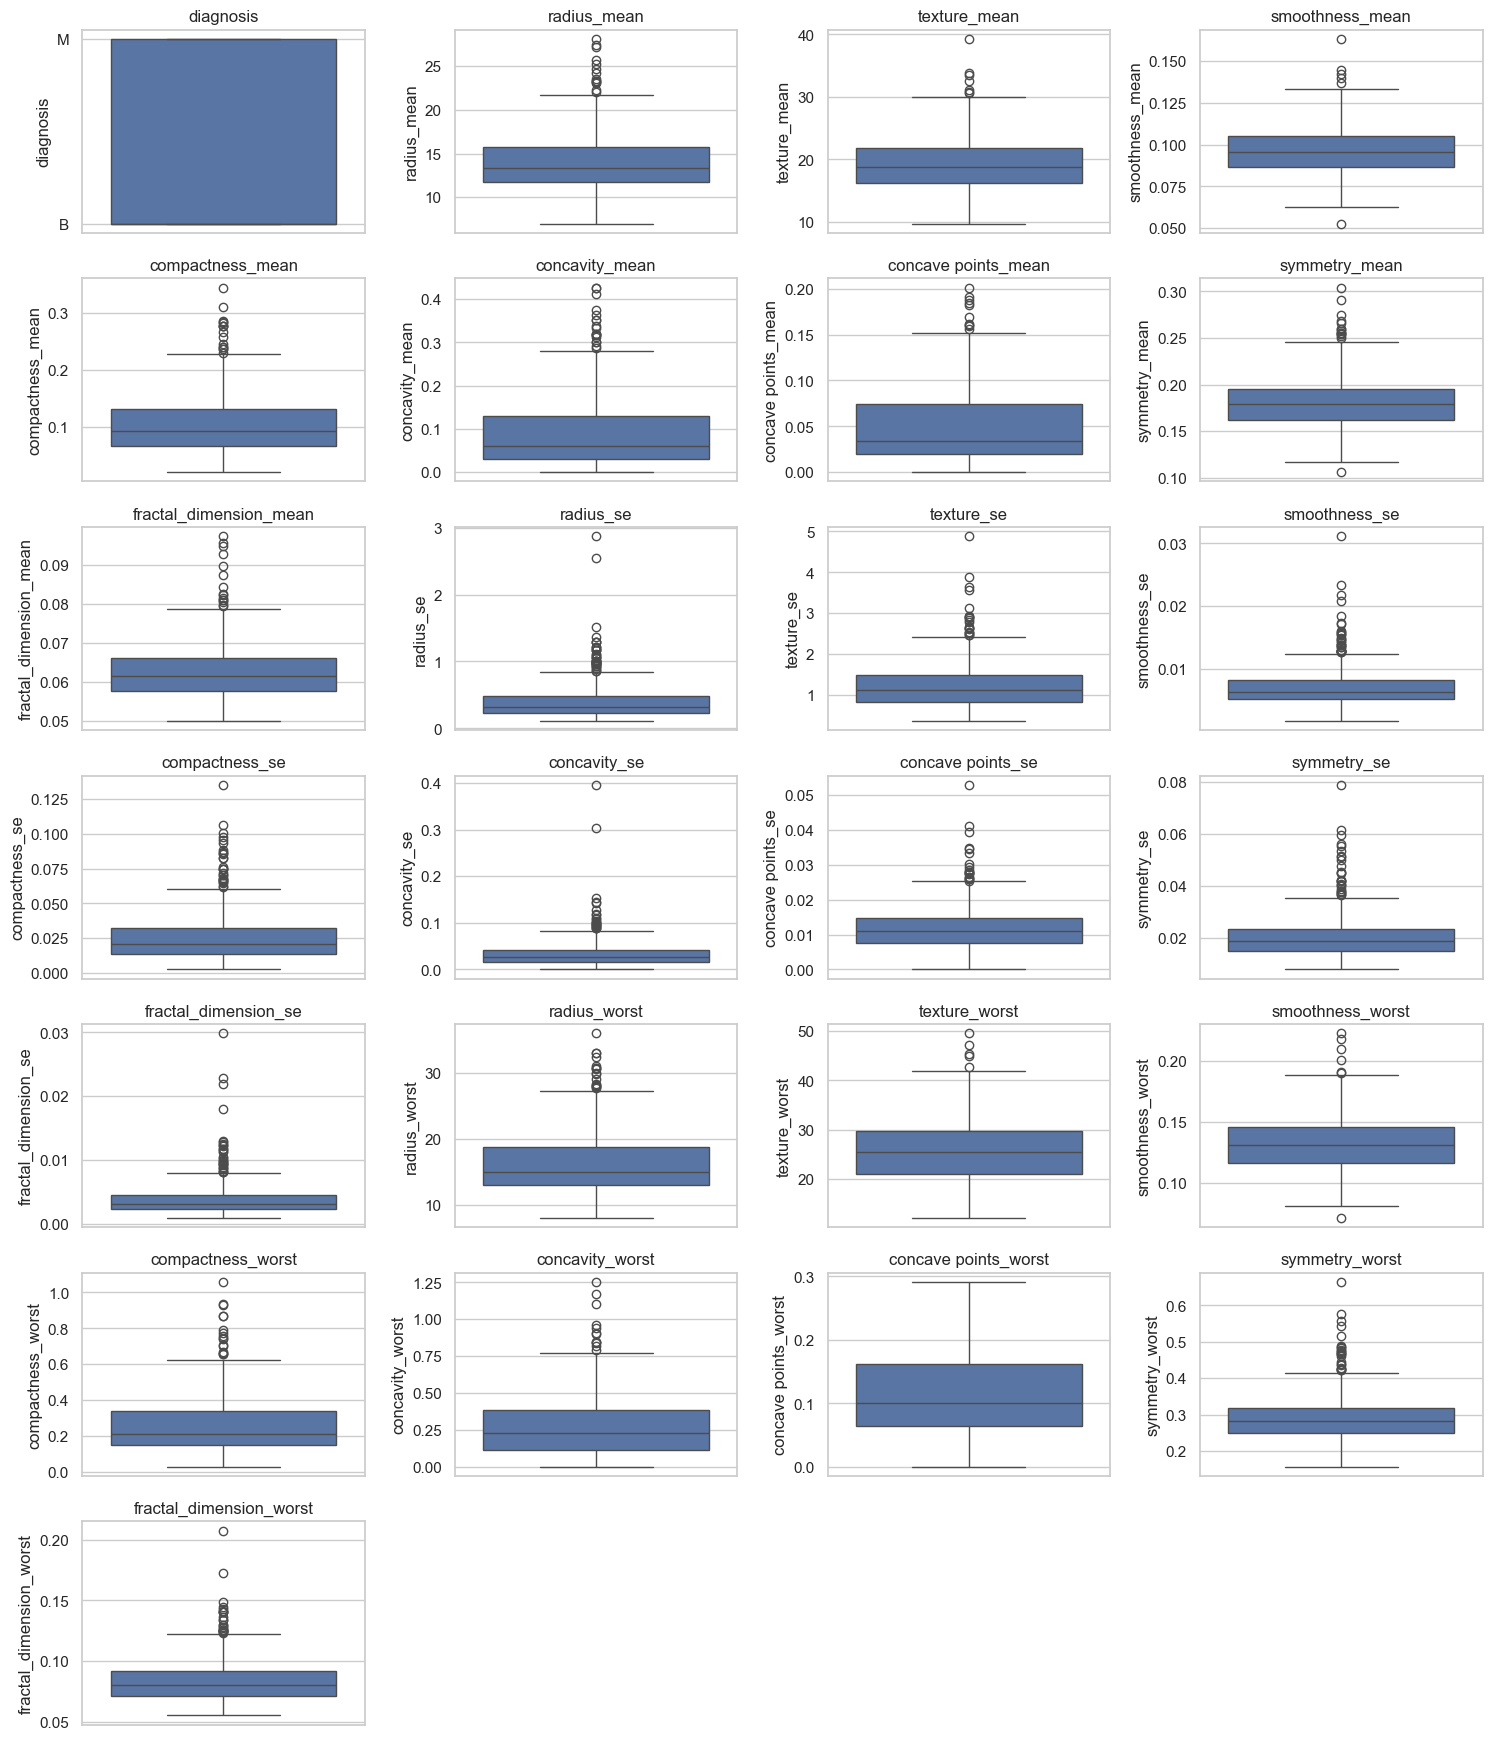

In [19]:
# Identifying Outliers
cols = Dataset.columns

plt.figure(figsize=(15, 20))

for i, col in enumerate(cols, 1):
    plt.subplot(8, 4, i)  # adjust grid
    sns.boxplot(y=Dataset[col])
    plt.title(col)

plt.tight_layout()

In [20]:
# Removing Outliers
def cap_outliers(df, multiplier=1.5):
    import numpy as np
    
    df_capped = df.copy()
    num_cols = df.select_dtypes(include=np.number).columns

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        
        df_capped[col] = np.clip(df[col], lower, upper)
    
    return df_capped
    
cleaned_data = cap_outliers(Dataset)

rows_removed = Dataset.shape[0] - cleaned_data.shape[0] # No row was removed, because the outlier was capped
print("Rows removed:", rows_removed)

Rows removed: 0


diagnosis
B    357
M    212
Name: count, dtype: int64


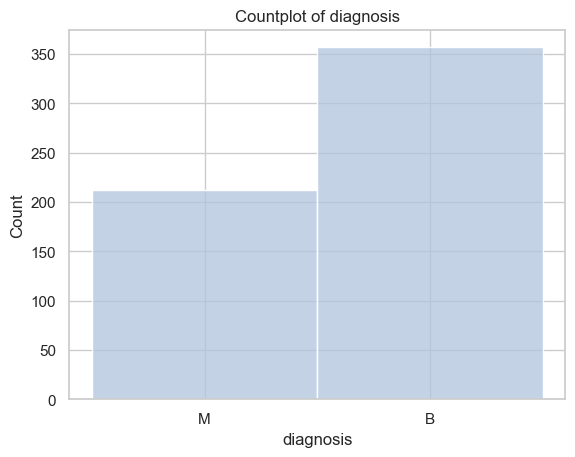

In [21]:
# Target Variable Analysis
print(cleaned_data['diagnosis'].value_counts())
sns.histplot(cleaned_data['diagnosis'], color='lightsteelblue')
plt.title(f"Countplot of diagnosis")
plt.show()

In [22]:
# Getting the ratio of imbalance
counts = Dataset['diagnosis'].value_counts()

percentages = (counts / counts.sum()) * 100

for label, value in percentages.items():
    print(f"{label}: {value:.2f}%")
print('='*80)

print('''\nThe dataset shows a moderate class imbalance between benign and malignant cases.
To address this, CLASS WEIGHTING and resampling techniques such as SMOTE were considered to ensure the model does not bias toward the majority class. 
              ''')

B: 62.74%
M: 37.26%

The dataset shows a moderate class imbalance between benign and malignant cases.
To address this, CLASS WEIGHTING and resampling techniques such as SMOTE were considered to ensure the model does not bias toward the majority class. 
              


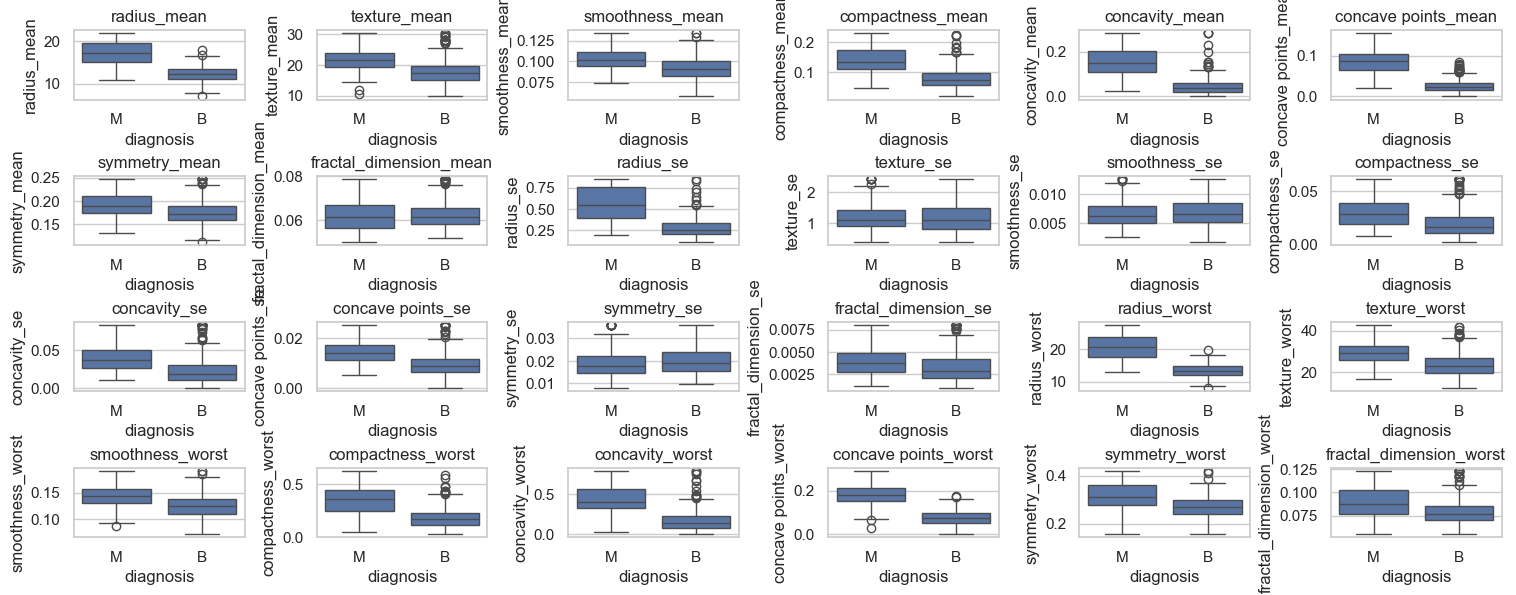

In [23]:
# Feature vs Target Relationship
plt.figure(figsize=(15, 10), constrained_layout=True)

features = ['radius_mean', 'texture_mean', 'smoothness_mean',
       'compactness_mean', 'concavity_mean', 'concave points_mean',
       'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se',
       'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se',
       'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'smoothness_worst', 'compactness_worst', 'concavity_worst',
       'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

for i, col in enumerate(features, 1):
    plt.subplot(10, 6, i)
    sns.boxplot(x='diagnosis', y=col, data=cleaned_data)
    plt.title(col)

plt.show()

In [24]:
print('\033[1mFeature vs Target Relationship\033[0m')
print('-'*30)
for col in features:
    mean_B = cleaned_data[cleaned_data['diagnosis']=='B'][col].mean()
    mean_M = cleaned_data[cleaned_data['diagnosis']=='M'][col].mean()

    print(f"{col}: B={mean_B:.2f}, M={mean_M:.2f}")

Feature vs Target Relationship
------------------------------
radius_mean: B=12.15, M=17.29
texture_mean: B=17.90, M=21.53
smoothness_mean: B=0.09, M=0.10
compactness_mean: B=0.08, M=0.14
concavity_mean: B=0.05, M=0.16
concave points_mean: B=0.03, M=0.09
symmetry_mean: B=0.17, M=0.19
fractal_dimension_mean: B=0.06, M=0.06
radius_se: B=0.28, M=0.55
texture_se: B=1.20, M=1.20
smoothness_se: B=0.01, M=0.01
compactness_se: B=0.02, M=0.03
concavity_se: B=0.02, M=0.04
concave points_se: B=0.01, M=0.01
symmetry_se: B=0.02, M=0.02
fractal_dimension_se: B=0.00, M=0.00
radius_worst: B=13.38, M=20.91
texture_worst: B=23.52, M=29.24
smoothness_worst: B=0.12, M=0.14
compactness_worst: B=0.18, M=0.36
concavity_worst: B=0.16, M=0.44
concave points_worst: B=0.07, M=0.18
symmetry_worst: B=0.27, M=0.32
fractal_dimension_worst: B=0.08, M=0.09


# STRONG FEATURES

**Size**
- radius_mean: B=12.15, M=17.29
- radius_worst: B=13.38, M=20.91

**Shape / Irregularity**
- concavity_mean: B=0.05, M=0.16
- concave points_mean: B=0.03, M=0.09
- concavity_worst: B=0.16, M=0.44
- concave points_worst: B=0.07, M=0.18

**Structure**
- compactness_mean: B=0.08, M=0.14
- compactness_worst: B=0.18, M=0.36

**Moderate Features**
- texture_mean: B=17.90, M=21.53
- texture_worst: B=23.52, M=29.24

**SE Features (mostly weak)**
- radius_se: B=0.28, M=0.55

In [25]:
selected_features = [
    'radius_mean',
    'radius_worst',
    'concavity_mean',
    'concave points_mean',
    'concavity_worst',
    'concave points_worst',
    'compactness_mean',
    'compactness_worst',
    'texture_mean',
    'texture_worst',
    'radius_se'
]

# Create new dataset
Dataset_selected = cleaned_data[selected_features + ['diagnosis']]

print('''\nAfter removing highly correlated features, the analysis revealed that features related to tumor size (radius), shape irregularity (concavity and concave points), and structural compactness provide the strongest discrimination between benign and malignant cases. Features such as smoothness, symmetry, and fractal dimension exhibited minimal variation and were excluded.”
''')


After removing highly correlated features, the analysis revealed that features related to tumor size (radius), shape irregularity (concavity and concave points), and structural compactness provide the strongest discrimination between benign and malignant cases. Features such as smoothness, symmetry, and fractal dimension exhibited minimal variation and were excluded.”



In [26]:
# Feature Importance Clues
print(f"Cleaned Data: \n{cleaned_data.nunique()}") # Checking for uniqueness
print('-'*30)
print(f"Dataset Selected: \n{Dataset_selected.nunique()}")

Cleaned Data: 
diagnosis                    2
radius_mean                443
texture_mean               473
smoothness_mean            470
compactness_mean           522
concavity_mean             520
concave points_mean        533
symmetry_mean              419
fractal_dimension_mean     485
radius_se                  503
texture_se                 500
smoothness_se              520
compactness_se             514
concavity_se               512
concave points_se          489
symmetry_se                472
fractal_dimension_se       518
radius_worst               441
texture_worst              507
smoothness_worst           406
compactness_worst          514
concavity_worst            528
concave points_worst       492
symmetry_worst             478
fractal_dimension_worst    514
dtype: int64
------------------------------
Dataset Selected: 
radius_mean             443
radius_worst            441
concavity_mean          520
concave points_mean     533
concavity_worst         528
concave

In [27]:
# Checking for Variant
print(f"Variance in cleaned_data: \n{cleaned_data.var(numeric_only=True)}") 
print('-'*30)
print(f"Variance in Dataset Selected: \n{Dataset_selected.var(numeric_only=True)}")

Variance in cleaned_data: 
radius_mean                11.155764
texture_mean               17.535244
smoothness_mean             0.000187
compactness_mean            0.002439
concavity_mean              0.005461
concave points_mean         0.001416
symmetry_mean               0.000679
fractal_dimension_mean      0.000041
radius_se                   0.041458
texture_se                  0.235710
smoothness_se               0.000006
compactness_se              0.000223
concavity_se                0.000423
concave points_se           0.000030
symmetry_se                 0.000043
fractal_dimension_se        0.000003
radius_worst               21.042850
texture_worst              36.655826
smoothness_worst            0.000498
compactness_worst           0.020406
concavity_worst             0.038991
concave points_worst        0.004321
symmetry_worst              0.002902
fractal_dimension_worst     0.000256
dtype: float64
------------------------------
Variance in Dataset Selected: 
radius_m

In [28]:
# Handling Skewed data 
# Check skewness for cleaned data
skewed_cleaned = cleaned_data.select_dtypes(include='number').skew()
print(f"Skewness in Cleaned Data: \n{skewed_cleaned}")

# Check skewness for selected dataset
skewed_selected = Dataset_selected.select_dtypes(include='number').skew()
print(f"\nSkewness in Selected Dataset: \n{skewed_selected}")

Skewness in Cleaned Data: 
radius_mean                0.655953
texture_mean               0.449700
smoothness_mean            0.257712
compactness_mean           0.826755
concavity_mean             1.023859
concave points_mean        1.004049
symmetry_mean              0.403621
fractal_dimension_mean     0.682430
radius_se                  1.025031
texture_se                 0.740987
smoothness_se              0.780923
compactness_se             0.990285
concavity_se               0.916740
concave points_se          0.539571
symmetry_se                0.869297
fractal_dimension_se       0.979344
radius_worst               0.849779
texture_worst              0.386858
smoothness_worst           0.247199
compactness_worst          0.915295
concavity_worst            0.809174
concave points_worst       0.492616
symmetry_worst             0.521772
fractal_dimension_worst    0.831581
dtype: float64

Skewness in Selected Dataset: 
radius_mean             0.655953
radius_worst            0.849

In [29]:
from scipy.stats import boxcox

# Function to transform skewed features
def handle_skewness(df, threshold=0.5):
    df_transformed = df.copy()
    num_cols = df.select_dtypes(include=np.number).columns
    
    for col in num_cols:
        skewness = df[col].skew()
        if skewness > threshold:  # right skew
            # Shift to avoid log(0)
            df_transformed[col] = np.log1p(df[col])
        elif skewness < -threshold:  # left skew
            # Use square or other transformation
            df_transformed[col] = np.sqrt(df[col].max() - df[col])
    return df_transformed

# Apply on both datasets
cleaned_data = handle_skewness(cleaned_data)
Dataset_selected = handle_skewness(Dataset_selected)

# Saving both to a pd DataFrame
cleaned_data.to_csv('cleaned_data.csv', index=False) 
Dataset_selected.to_csv('Dataset_selected.csv', index=False) 

In [30]:
cleaned_data.head(2)

,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,...,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,2.943913,10.38,0.11840,0.205892,0.248741,0.137237,0.2419,0.075766,0.614456,...,0.029588,0.006174,3.272606,17.33,0.1622,0.486707,0.537604,0.2654,0.350058,0.112346
1,M,3.071303,17.77,0.08474,0.075701,0.083330,0.067818,0.1812,0.055122,0.434053,...,0.013794,0.003526,3.257712,23.41,0.1238,0.171092,0.216401,0.1860,0.242946,0.085278


In [31]:
# Separating Features
X = cleaned_data.iloc[:, 1:]
y = cleaned_data.iloc[:, 0]

In [32]:
# Encoding Feature Variable 
le = LabelEncoder()
y = le.fit_transform(y)

is_numpy = isinstance(y, np.ndarray)
print(is_numpy)

True


In [33]:
# Spliting and Feature Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)  # Spliting into train set

print(X_train.shape)
print(y_train.shape)

(455, 24)
(455,)


In [34]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Converting to numpy array
X_train = X_train
X_test = X_test

# Model Building

In [48]:
# Trining multiple model
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}


results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    }

# Display results
for model, metrics in results.items():
    print(f"\n{model}")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
        
print(f"\n{'='*150}")
print('''“Among the evaluated models, Logistic Regression achieved the best performance with the highest recall (0.9767) and F1-score (0.9545), making it the most suitable model for predicting malignant cases. This is particularly important in medical diagnosis where minimizing false negatives is critical.”
''')


Logistic Regression
Accuracy: 0.9649
F1 Score: 0.9545
Recall: 0.9767

Random Forest
Accuracy: 0.9649
F1 Score: 0.9524
Recall: 0.9302

SVM
Accuracy: 0.9649
F1 Score: 0.9535
Recall: 0.9535

KNN
Accuracy: 0.9561
F1 Score: 0.9425
Recall: 0.9535

“Among the evaluated models, Logistic Regression achieved the best performance with the highest recall (0.9767) and F1-score (0.9545), making it the most suitable model for predicting malignant cases. This is particularly important in medical diagnosis where minimizing false negatives is critical.”



In [46]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[68  3]
 [ 2 41]]


In [45]:
# Tunning the Model
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(LogisticRegression(class_weight='balanced'),
                    param_grid, cv=5)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'C': 0.1, 'solver': 'lbfgs'}


In [47]:
# Traning final model
final_model = LogisticRegression(C=0.1, solver='lbfgs', class_weight='balanced')

final_model.fit(X_train, y_train)

# Predicting on test set
y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


print(f"\n{'='*150}")
print('''“Hyperparameter tuning using GridSearchCV identified the optimal Logistic Regression model with C = 0.1 and solver = ‘lbfgs’. The lower C value introduces stronger regularization, improving generalization and reducing overfitting. This optimized model achieved the best balance between recall and precision, making it suitable for medical diagnosis.”
''')


              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

[[69  2]
 [ 1 42]]

“Hyperparameter tuning using GridSearchCV identified the optimal Logistic Regression model with C = 0.1 and solver = ‘lbfgs’. The lower C value introduces stronger regularization, improving generalization and reducing overfitting. This optimized model achieved the best balance between recall and precision, making it suitable for medical diagnosis.”



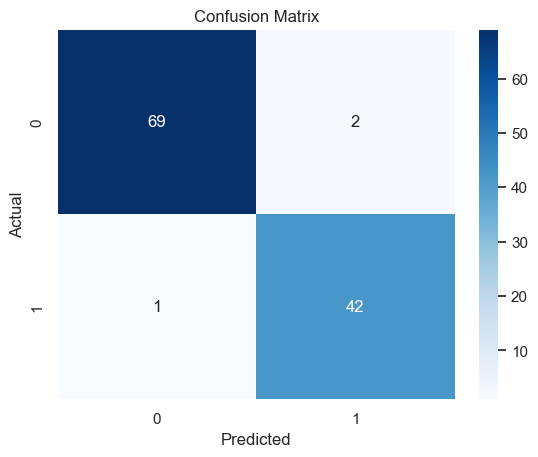


“The confusion matrix shows that the model correctly classified 69 benign and 42 malignant cases. Only 2 benign cases were misclassified as malignant, and 1 malignant case was incorrectly classified as benign. The low number of false negatives demonstrates the model’s strong ability to detect malignant cases.”



In [39]:
# Plotting confusion metrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(f"\n{'='*150}")
print('''“The confusion matrix shows that the model correctly classified 69 benign and 42 malignant cases. Only 2 benign cases were misclassified as malignant, and 1 malignant case was incorrectly classified as benign. The low number of false negatives demonstrates the model’s strong ability to detect malignant cases.”
''')

In [40]:
# # ROC Curve + AUC Code

# y_prob = final_model.predict_proba(X_test)[:, 1] # Get probability scores

# # Compute ROC curve
# fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# # Compute AUC
# roc_auc = auc(fpr, tpr)

# # Plot
# plt.figure(figsize=(8,6))
# plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
# plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line

# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.legend()
# plt.show()


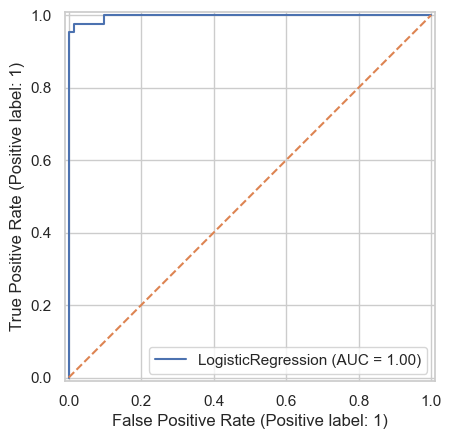

“The ROC curve demonstrates the model’s ability to distinguish between benign and malignant cases across different thresholds. The AUC score of approximately (0.9974) indicates excellent classification performance.”



In [41]:
# ROC Curve + AUC Code
RocCurveDisplay.from_estimator(final_model, X_test, y_test)
plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line
plt.show()

print('''“The ROC curve demonstrates the model’s ability to distinguish between benign and malignant cases across different thresholds. The AUC score of approximately (0.9974) indicates excellent classification performance.”
''')

In [42]:
# Applying K-fold Cross Validation

# Reshape y_train and y_test
y_train = y_train.ravel()
y_test = y_test.ravel()

# Applying K-Fold Cross Validation
accuracies = cross_val_score(estimator=final_model, X=X_train, y=y_train, cv=10)

# Calculate mean and std
mean_accuracy = np.mean(accuracies) * 100
std_accuracy = np.std(accuracies) * 100

# Display accuracies in a table
print("Accuracies:")
print(tabulate([accuracies * 100], headers=[f"Fold {i+1}" for i in range(10)], tablefmt="grid"))
print(f"\nMean Accuracy: {mean_accuracy:.2f}%")
print(f"Standard Deviation: {std_accuracy:.2f}%")

Accuracies:
+----------+----------+----------+----------+----------+----------+----------+----------+----------+-----------+
|   Fold 1 |   Fold 2 |   Fold 3 |   Fold 4 |   Fold 5 |   Fold 6 |   Fold 7 |   Fold 8 |   Fold 9 |   Fold 10 |
+==========+==========+==========+==========+==========+==========+==========+==========+==========+===========+
|  97.8261 |  97.8261 |  97.8261 |  95.6522 |      100 |      100 |  97.7778 |  97.7778 |  95.5556 |   95.5556 |
+----------+----------+----------+----------+----------+----------+----------+----------+----------+-----------+

Mean Accuracy: 97.58%
Standard Deviation: 1.55%


# Model Deployment

In [43]:
import pickle

# Save model
pickle.dump(final_model, open('BCC_model.pkl', 'wb'))

# Save scaler
pickle.dump(sc, open('scaler.pkl', 'wb'))

In [1]:
import numpy as np
List = np.array([[2,3], [6,5]])

In [5]:
print(f"A = {List}")

A = [[2 3]
 [6 5]]
